In [1]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as ss
from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

In [2]:
# load files
path_data = '../data/'
data_spectra = fits.getdata(path_data + 'flux_norm_paq12_6173_lionel_tau1_scalingspatial1_sansrotation.fits')
data_rv = readsav(path_data + 'res_rv_bis_6173_lionel_tau1_scaling1_sansrot.sav')

In [3]:
c = 3e8
# extract data
wl = data_rv['lambd']
rv = data_rv['rv_correl']
template = data_rv['flux_moy']
times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days

In [4]:
# mean spectrum
mean_spec = np.mean(data_spectra, axis=0)  # calculate mean spectrum (i.e. the mean flux for each wl)
# take out projection over the velocity vector
S_f, D = t.subtract_v(wl, data_spectra, c=3e8)  # speed of light in m/s

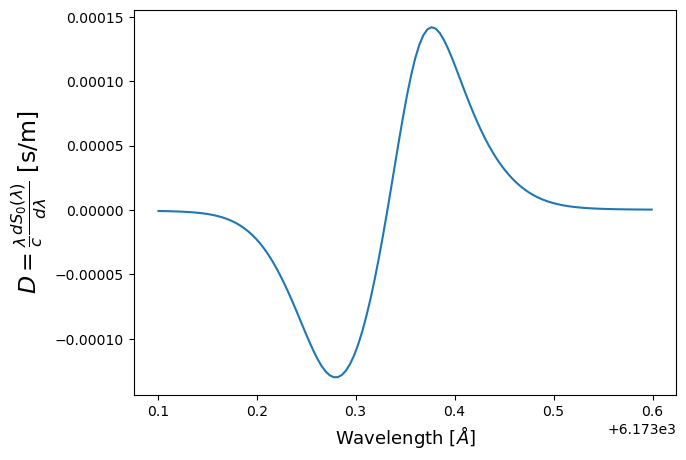

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(wl, D)
ax.set_xlabel(r'Wavelength [$\AA$]', size=13)
ax.set_ylabel(r'$D = \frac{\lambda}{c} \frac{dS_0(\lambda)}{d\lambda}$ [s/m]', size=17)
plt.show()

### RV by TM

In [44]:
# calculate radial velocity by template matching
C_0 = 10**4
rv_tm = []
for k in range(len(data_spectra)):  # for each spectrum
    rv_tm.append(t.calculate_rv(wl, mean_spec, data_spectra[k], C_0))
rv_tm = np.array(rv_tm)

In [57]:
R = np.array([(i - mean_spec) for i in data_spectra])
#alpha = np.array([(np.cov(i, D) / np.std(D)**2)[0, 1] for i in R])
alpha = np.dot(R, D) / np.linalg.norm(D)**2
print(R[0].shape, D.shape, alpha.shape)

(122,) (122,) (3686,)


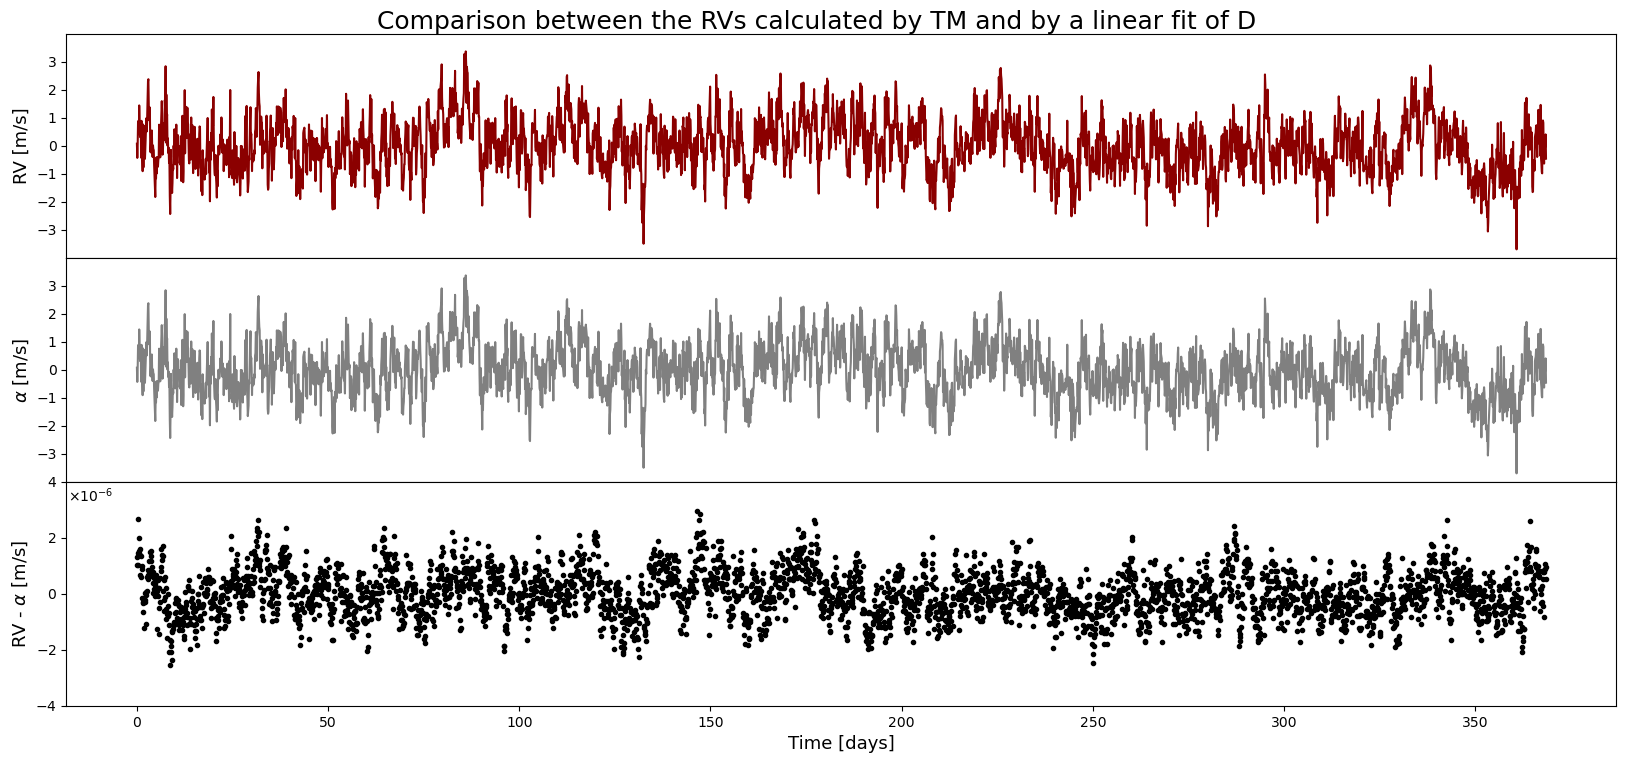

In [59]:


fig, axs = plt.subplots(3, 1, figsize=(20, 8), sharex=True)
fig.suptitle('Comparison between the RVs calculated by TM and by a linear fit of D', size=18)

axs[0].plot(times, rv_tm, color='darkred')  # RV calculated by Etienne
axs[0].set_ylabel('RV [m/s]', size=13)
axs[0].set_ylim(-4, 4)
axs[0].set_yticks([-3, -2, -1, 0, 1, 2, 3])

axs[1].plot(times, alpha, color='gray')
axs[1].set_ylabel(r'$\alpha$ [m/s]', size=13)
axs[1].set_ylim(-4, 4)
axs[1].set_yticks([-3, -2, -1, 0, 1, 2, 3])

axs[2].scatter(times, rv_tm - alpha, marker='.', color='k')
axs[2].set_xlabel(r'Time [days]', size=13)
axs[2].set_ylabel(r'RV - $\alpha$ [m/s]', size=13)
#axs[2].set_ylim(-4e-5, 4e-5)
#axs[2].set_yticks(np.array([-3, -2, -1, 0, 1, 2, 3])*10**-5)
locs = t.move_sn_y(offs=-.181, side='left')

plt.subplots_adjust(hspace=0, top=.95)
plt.show()

## Calculate RV by CCF

In [7]:
#lambda_ref = wl[np.argmin(mean_spec)]  # pick a reference wavelength: I choose the one corresponding to the minimum flux of the reference spectrum
#delta_lambda = wl - lambda_ref  # Angstrom
#vels = c * delta_lambda / wl  # m / s
delta_vel = np.linspace(-5, 5, 201)  # define RV grid
lambda_vr = np.array([wl * np.sqrt((1 - v / c) / (1 + v / c)) for v in delta_vel])  # wavelength grid for each v

In [8]:
# interpolate flux over lambda_vr to fit the originl wavelength grid (wl)
shifted_mask = []  # list of shifted masks, corresponding to each delta_vel
for wl_grid in lambda_vr:  # iterate over wavelength grids
    shifted_mask.append(np.interp(wl, wl_grid, mean_spec))
shifted_mask = np.array(shifted_mask)

In [9]:
# calculate CCF between each measured spectrum and the reference spectrum
ccf = []
for j in tqdm(range(len(data_spectra))):  # iterate over measured (simulated) spectra
    ccf.append(np.array([sum(t.cross_correlate(data_spectra[j], shifted_mask[i])) for i in range(len(delta_vel))]))  # CCF
ccf = np.array(ccf)

100%|██████████| 3686/3686 [00:15<00:00, 233.17it/s]


In [10]:
# fit a gaussian to each CCF
params = []
models = []
for i in tqdm(range(len(ccf))):  # iterate over CCF indices
    params_i, _ = curve_fit(t.gaussian, delta_vel, ccf[i], p0=[max(ccf[i])- min(ccf[i]), 0, np.std(delta_vel), np.max(ccf[i])])  # fit a gaussian to the CCF and save the parameters
    model_i = t.gaussian(delta_vel, params_i[0], params_i[1], params_i[2], params_i[3])  # calculate the model using the obtained parameters
    params.append(params_i)  # save parameters
    models.append(model_i)  # save model
params = np.array(params)
models = np.array(models)
mean_vels = params[:, 1]  # recover the position of the peak of each gaussian

  0%|          | 0/3686 [00:00<?, ?it/s]/tmp/ipykernel_2644740/2715889321.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  params_i, _ = curve_fit(t.gaussian, delta_vel, ccf[i], p0=[max(ccf[i])- min(ccf[i]), 0, np.std(delta_vel), np.max(ccf[i])])  # fit a gaussian to the CCF and save the parameters
100%|██████████| 3686/3686 [00:08<00:00, 426.23it/s]


In [11]:
rv_ccf = mean_vels

## Apply PCA

In [29]:
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(S_f)
# spectra_centered = S_f

In [30]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [9.95650644e-01 3.88689276e-03 4.07610987e-04 4.37927385e-05
 9.63240080e-06 9.04534451e-07 3.22201375e-07 1.00667069e-07
 5.88316424e-08 2.63756498e-08 3.79381685e-09 2.36308031e-09
 7.34912677e-10 6.55063953e-10 3.31847864e-10 3.29149456e-10
 3.22758152e-10 3.06592234e-10 3.02696425e-10 2.80749105e-10]


In [ ]:
# save loadings and scores
loadings = pca_flux.components_
scores = np.array([pcs[:, i] for i in range(n_components)])

In [31]:
# component significance
# multiple realizations allow to calculate error bars
n_realizations = 20
snr = 5e3
sigma = 1 / snr
mean_maxes = t.calculate_pca_significance(n_realizations, n_components, spectra_centered, sigma)  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.21it/s]


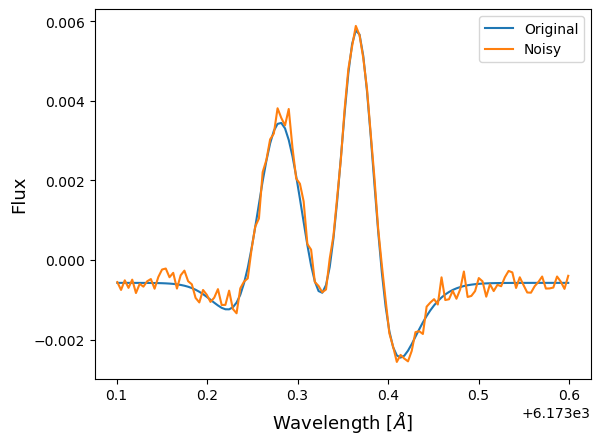

In [ ]:
# show noise
spectra_noisy = spectra_centered + np.random.normal(0, sigma, len(wl))  # add gaussian noise to the original data
plt.plot(wl, spectra_centered[0], label='Original')
plt.plot(wl, spectra_noisy[0], label='Noisy')
plt.xlabel(r'Wavelength [$\AA$]', size=13)
plt.ylabel('Flux', size=13)
plt.legend()
plt.show()

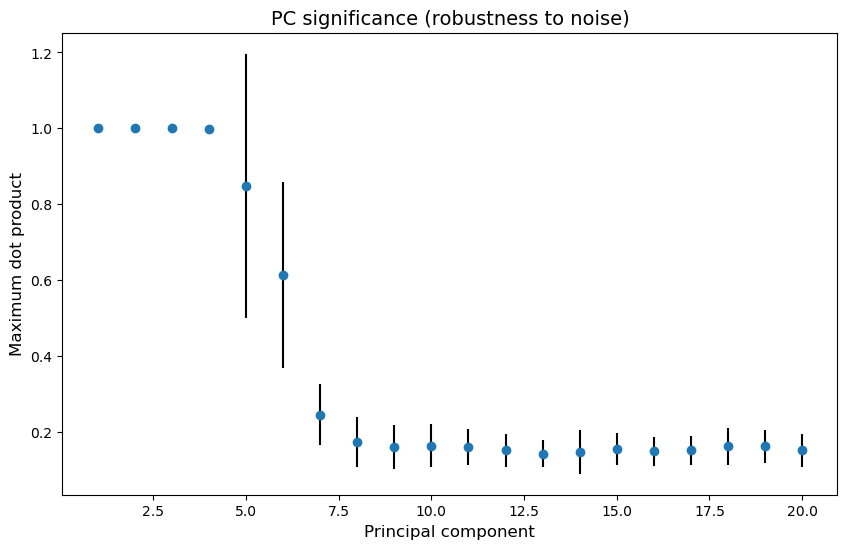

In [33]:
# plot component significance
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('PC significance (robustness to noise)', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [ ]:
# calculate power spectrum
dt = times[1] - times[0]
sp = np.array([np.fft.fft(scores) for i in range(n_components)])
freq = np.array([np.fft.fftfreq(scores.shape[0], dt) for i in range(n_components)])
power = np.abs(sp)**2

#periodograms = [LombScargle(times, scores).autopower() for i in range(n_components)]

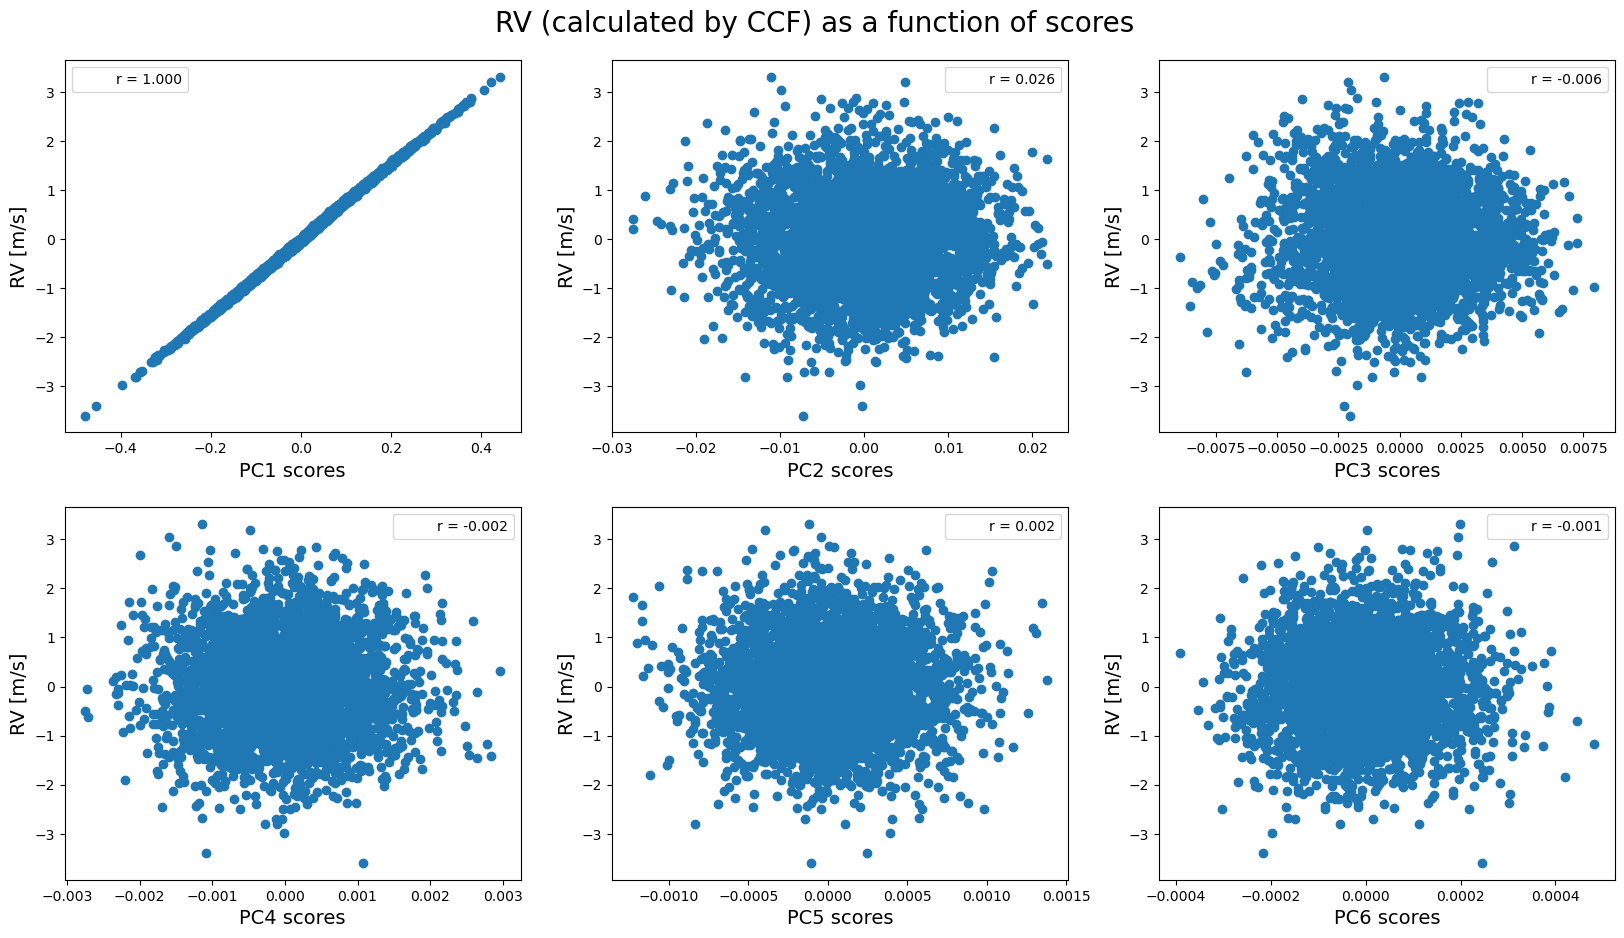

In [36]:
# RV (CCF) as a function of scores

rows = 2
cols = 3
fig, axs = plt.subplots(rows, cols, figsize=(20, 10))
fig.suptitle('RV (calculated by CCF) as a function of scores', size=20)

r = -1
k = 0
for i in range(6):
    if i % cols == 0:
        r += 1  # advance to the next column
        k = 0  # reset row
    # RV as a function of scores
    axs[r][k].scatter(scores[i], rv_ccf)
    axs[r][k].axvline(0, color='w', label=f'r = {ss.pearsonr(scores[i], rv_ccf)[0]:.3f}', zorder=-1)
    axs[r][k].set_xlabel(f'PC{i+1} scores', size=14)
    axs[r][k].set_ylabel('RV [m/s]', size=14)
    axs[r][k].legend()
    k += 1

plt.subplots_adjust(top=.93)
plt.show()

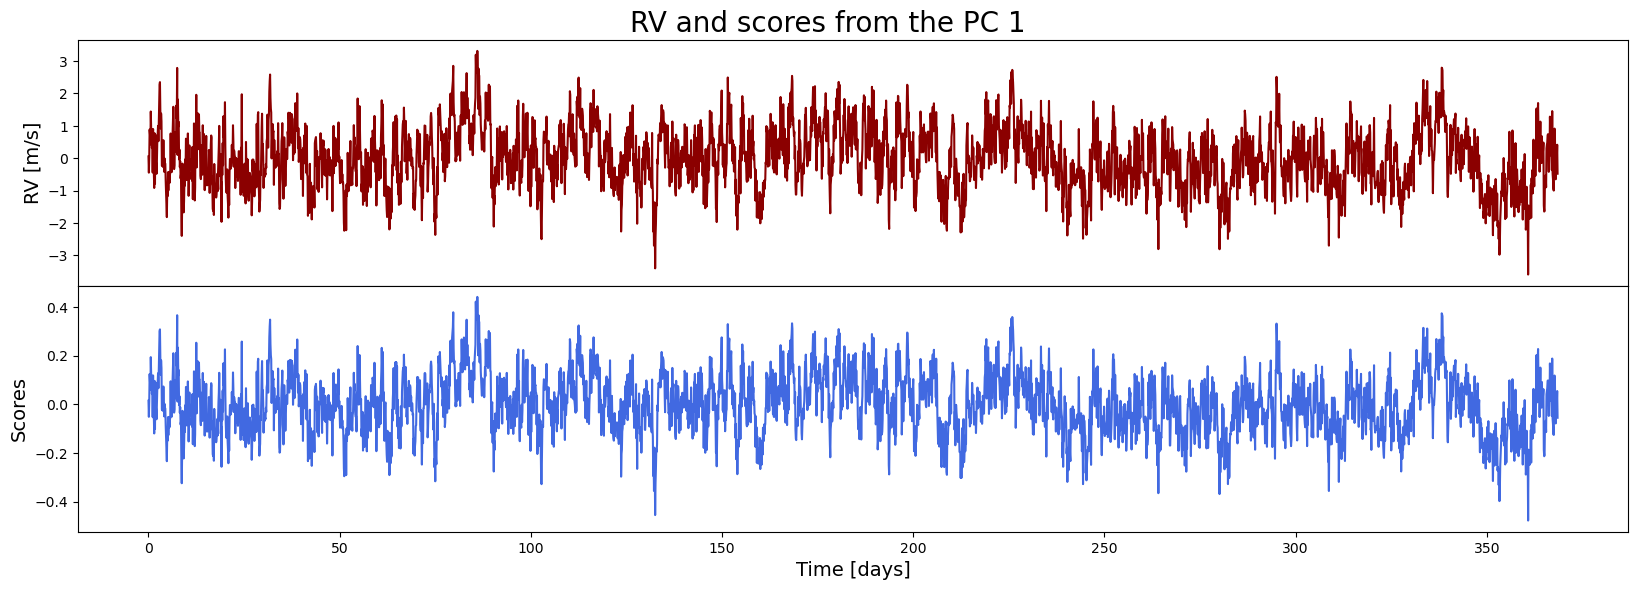

In [37]:
fig, axs = plt.subplots(2, 1, figsize=(20, 6), sharex=True)
fig.suptitle('RV and scores from the PC 1', size=20)

axs[0].plot(times, rv_ccf, color='darkred')
axs[0].set_ylabel('RV [m/s]', size=14)

axs[1].plot(times, scores[0], color='royalblue')
axs[1].set_ylabel('Scores', size=14)
axs[1].set_xlabel('Time [days]', size=14)

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

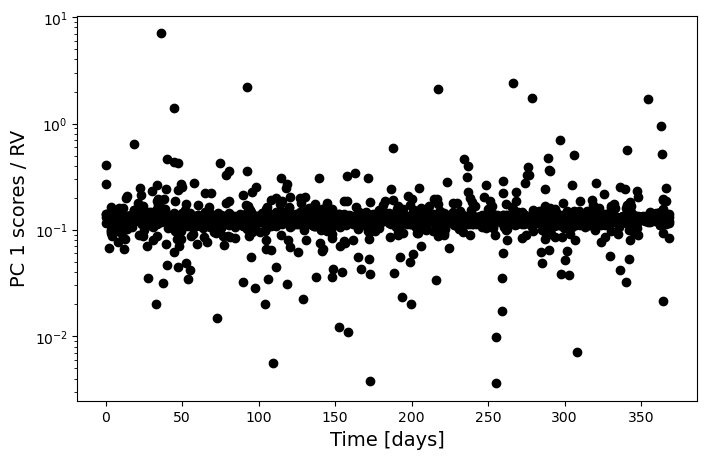

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(times, scores[0] / rv_ccf, color='k')
ax.set_yscale('log')
ax.set_xlabel('Time [days]', size=14)
ax.set_ylabel('PC 1 scores / RV', size=14)

plt.show()

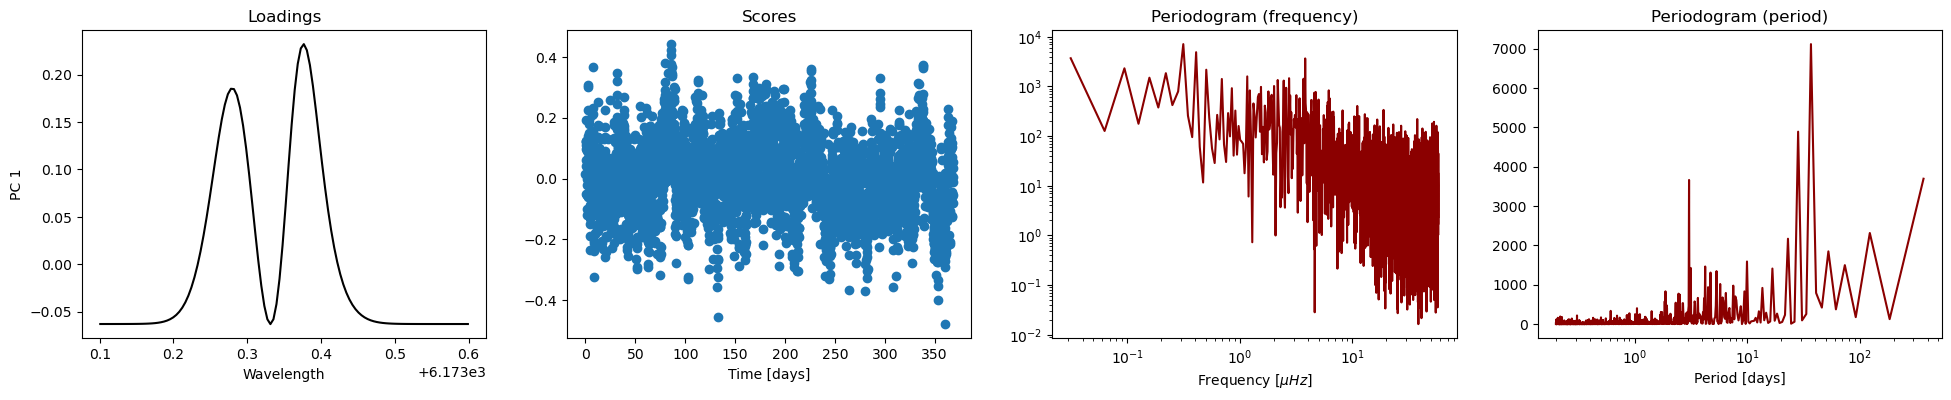

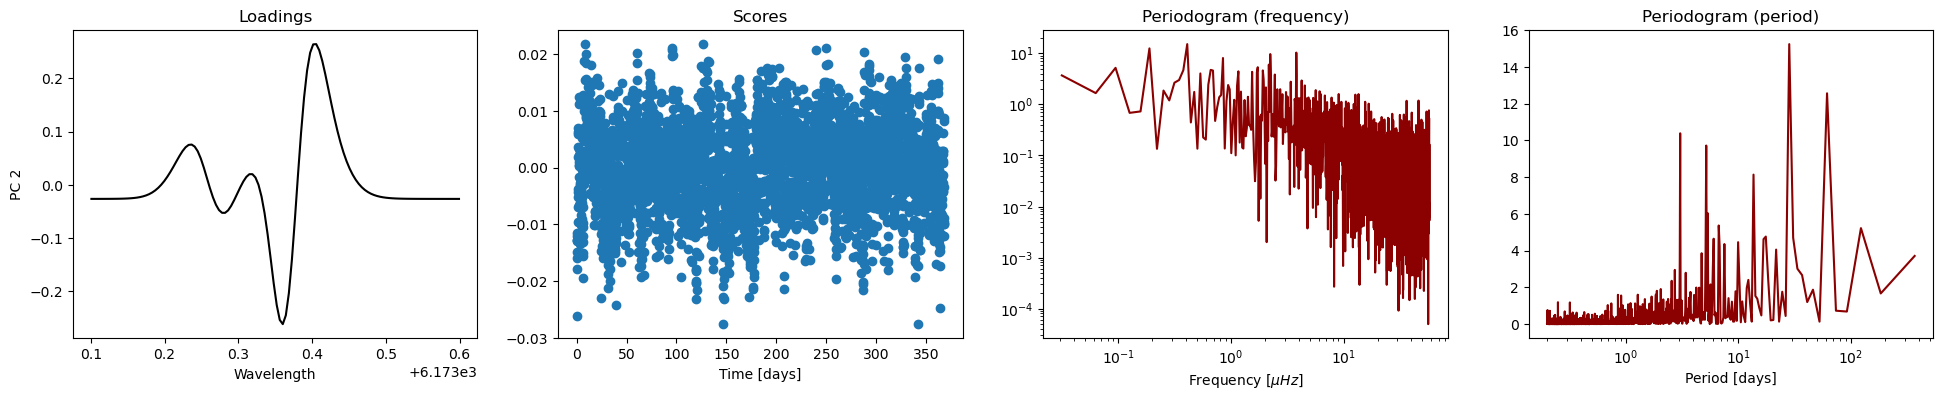

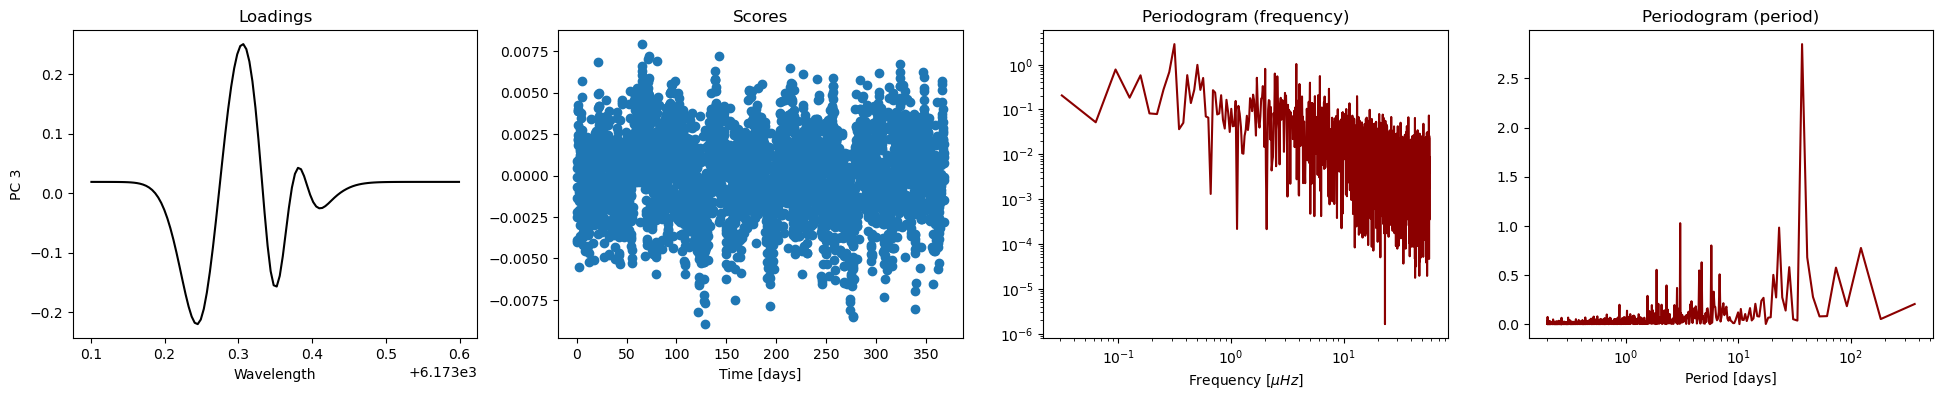

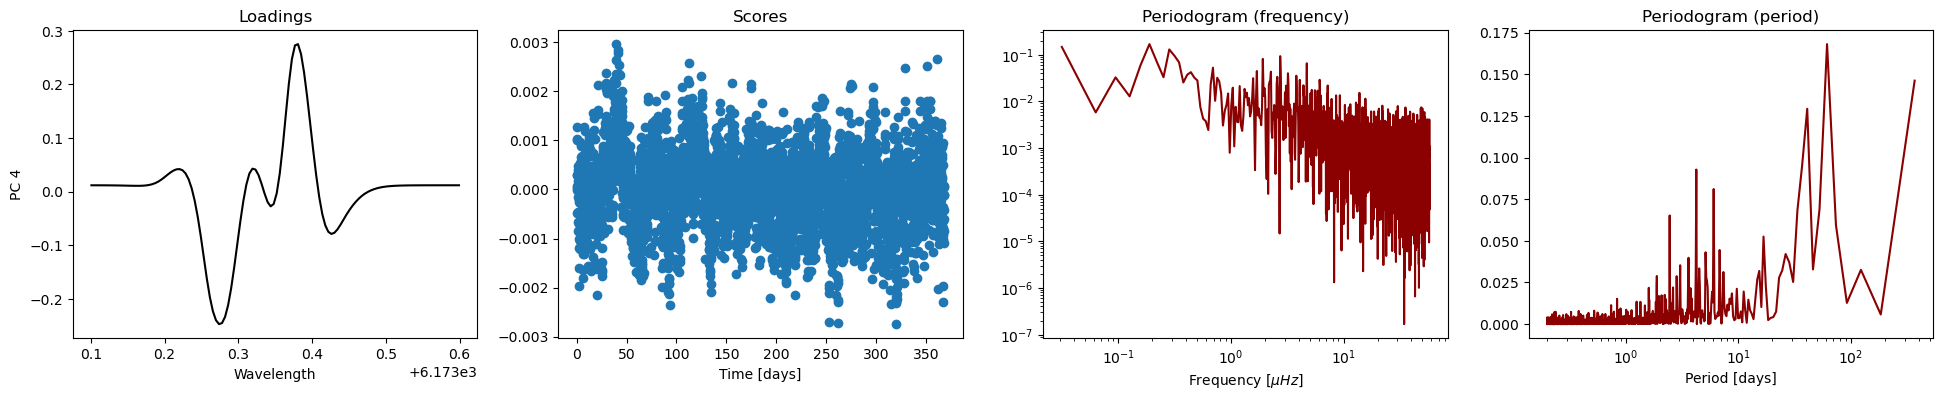

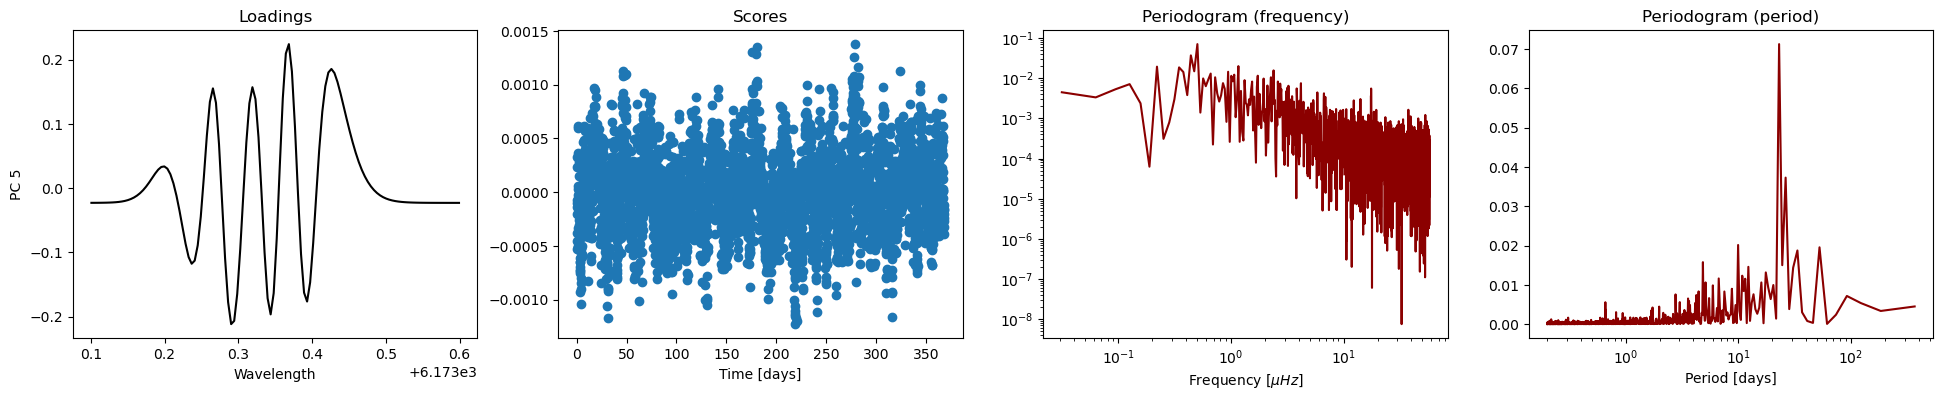

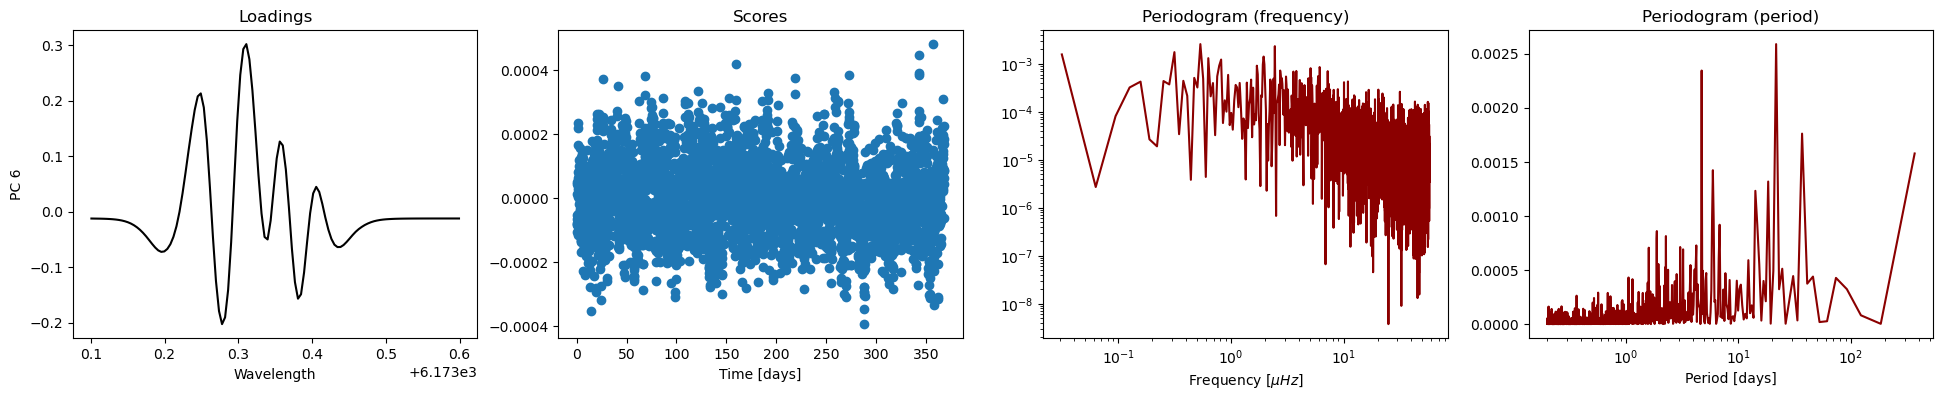

In [39]:
# plot
for i in range(6):
    fig, axs = plt.subplots(1, 4, figsize=(24, 4))
    
    # Loadings
    axs[0].plot(wl, loadings[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, scores[i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[2].plot(freq[i][mask] / 86400 * 10**6, power[i][mask], color='darkred')  # frequency divided by 86400 to pass from days^-1 to Hz, then multiplied by 10^6 to pass to microhertz
    axs[2].set_yscale('log')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram (frequency)', size=12)
    axs[2].set_xlabel(r'Frequency [$\mu Hz$]')

    # Fourier periodogram (period)
    axs[3].plot(1 / freq[i][mask], power[i][mask], color='darkred')
    #axs[3].set_yscale('log')
    axs[3].set_xscale('log')
    axs[3].set_title('Periodogram (period)', size=12)
    axs[3].set_xlabel('Period [days]')
    
    plt.show()

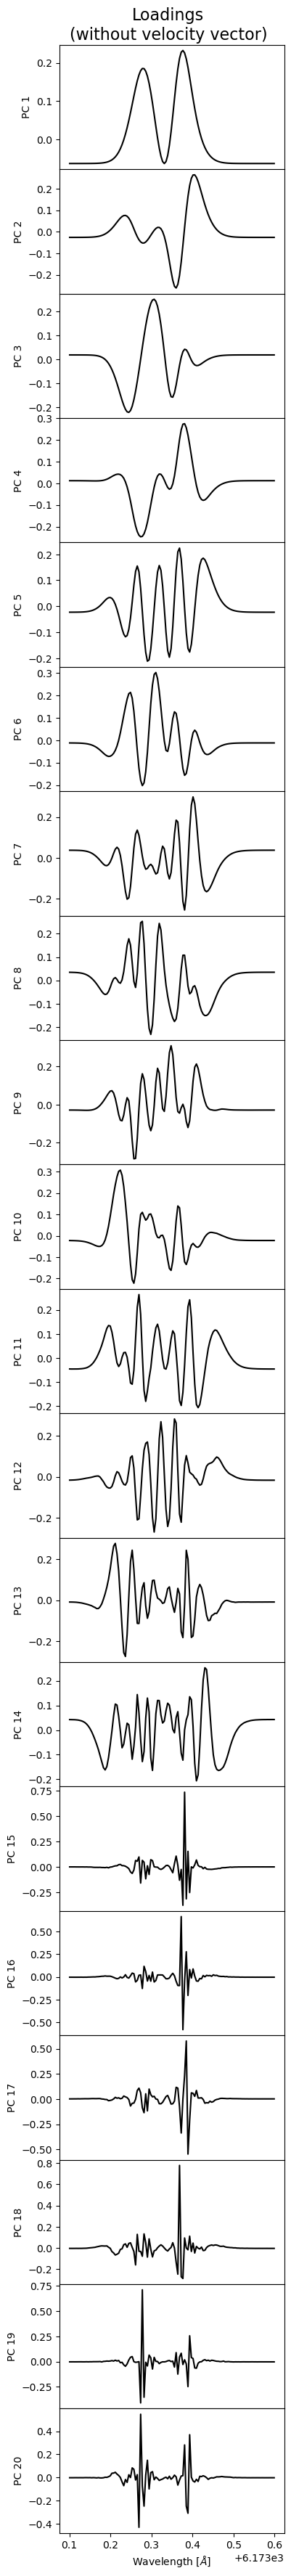

In [40]:
# all loadings
fig, axs = plt.subplots(n_components, 1, figsize=(4, 40), sharex=True)
fig.suptitle('Loadings\n(without velocity vector)', size=16)

for i in range(n_components):
    axs[i].plot(wl, loadings[i], color='k')
    axs[i].set_ylabel(f'PC {i + 1}')

axs[-1].set_xlabel(r'Wavelength [$\AA$]')

plt.subplots_adjust(hspace=0, top=.967)
plt.show()